In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [157]:
from matplotlib import pyplot as plt
import numpy as np
import sys
import tifffile as tf
import os
sys.path.append('..')
from neurotrack.data import neuron_data
from neurotrack.data import DrawingComplexityConfig

In [158]:
complexity_config = DrawingComplexityConfig()
data_generator = neuron_data.DataGenerator(cache_dir="../data_cache", complexity_config=complexity_config)

In [159]:
data_generator.empty_cache()

Cache directory ../data_cache emptied.


In [162]:
swc_root = "/home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subsubset"
img_root = "/home/brysongray/data/neurotrack_data/gold166/gold166_tifs_processed"
# img_root = None
data_generator.generate_data(swc_dir=swc_root, img_dir=img_root, subtrees_per_swc=1, complexity_range=(0.0, 1.0), n_steps=6, morphology="any")

Processing 3 SWC files...
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subsubset/091201c1.swc
Adjusted file prefix to avoid duplicate: 091201c1_subtree_06
Processed 091201c1: 1 subtrees generated
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subsubset/080926a.swc
Adjusted file prefix to avoid duplicate: 080926a_subtree_06
Processed 080926a: 1 subtrees generated
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subsubset/091202c2.swc
Adjusted file prefix to avoid duplicate: 091202c2_subtree_06
Processed 091202c2: 1 subtrees generated
Appended entry data to existing CSV: ../data_cache/generated_data_entries.csv

Processing complete!
Total subtrees generated: 3
Results saved to: ../data_cache


{'processed_files': 3, 'total_subtrees': 3, 'output_dir': '../data_cache'}

In [163]:
# Test sampling from the dataset
dataset = neuron_data.Dataset(data_generator.cache_dir)
for e in dataset.entries:
    print(e['neuron_name'])
print(dataset.get_complexity_distribution())

dataloader = neuron_data.DataLoader(dataset, complexity=1.0, morphology="any", stochastic_complexity=False)

091201c1_subtree_00
091201c1_subtree_01
091201c1_subtree_02
091201c1_subtree_03
091201c1_subtree_04
091201c1_subtree_05
080926a_subtree_00
080926a_subtree_01
080926a_subtree_02
080926a_subtree_03
080926a_subtree_04
080926a_subtree_05
091202c2_subtree_00
091202c2_subtree_01
091202c2_subtree_02
091202c2_subtree_03
091202c2_subtree_04
091202c2_subtree_05
091201c1_subtree_06
080926a_subtree_06
091202c2_subtree_06
{'morphology_distribution': {'simple': 13, 'complex': 7, 'moderate': 1}, 'complexity_stats': {'mean': 0.5714285714285714, 'std': 0.36140316116210053, 'min': 0.0, 'max': 1.0}}


In [78]:
dataloader.set_complexity(0.6)
dataloader.weights

[0.0,
 0.0,
 0.0,
 0.16666666666666666,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.16666666666666666,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.16666666666666666,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.16666666666666666,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.16666666666666666,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.16666666666666666,
 0.0,
 0.0]

Sampled image path: ../data_cache/080926a_subtree_06_image.tif
Sampled complexity: 1.0


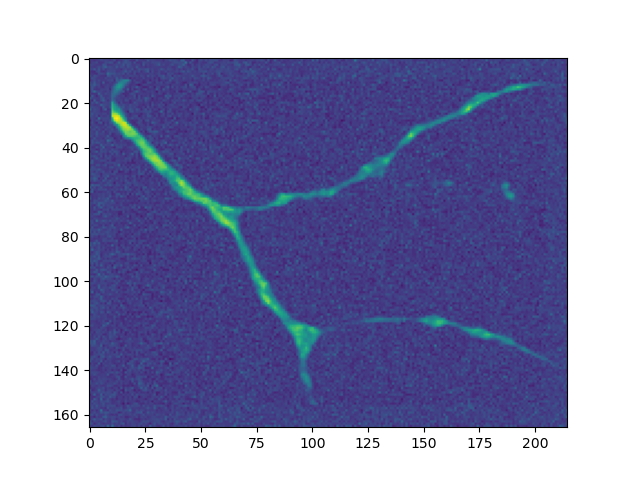

0.040650044
0.06706427


In [209]:
dataloader.set_complexity(1.0)
dataloader.set_morphology("any")

entry = dataloader.sample()
img_path = entry['img_path']
print(f"Sampled image path: {img_path}")
print(f"Sampled complexity: {entry['complexity']}")
img = tf.imread(img_path)

if img.dtype != np.float32:
    img = img.astype(np.float32) / img.max()

plt.close('all')
fig = plt.figure()
plt.imshow(img[0].max(axis=0), vmin=0, vmax=1)
plt.show()
print(img.mean())
print(img.std())

In [123]:
img.mean()

0.017250782

In [ ]:
tifs_dir = "/home/brysongray/data/neurotrack_data/gold166/gold166_training_set/images"

# load each tif

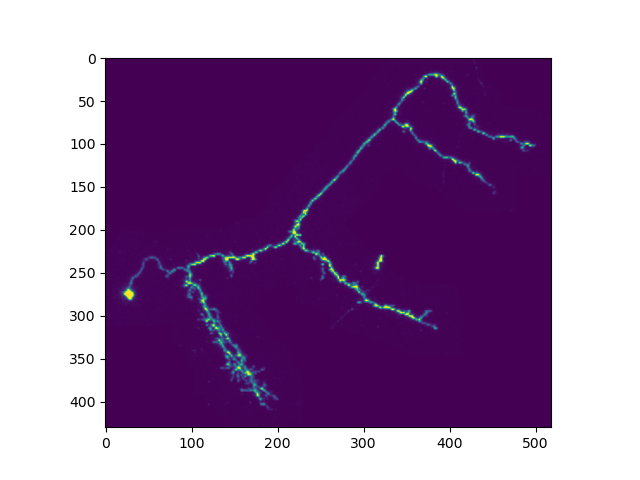

In [16]:
# plot a tif max projection one at a time
i = 9

fig = plt.figure()
img = tf.imread(os.path.join(tifs_dir, os.listdir(tifs_dir)[i]))
if img.dtype != np.float32:
    img = img.astype(np.float32) / img.max()
plt.imshow(img.max(axis=0), vmin=0, vmax=1)
plt.show()